In [7]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.odr import ODR, Model, RealData
%run ./Sample_Params_Constants.ipynb

In [8]:
data300=pd.read_csv('SQUID_csv/TbIG_1T_hysteresis_300_17Nov2024.dat.csv', header=None)
data275=pd.read_csv('SQUID_csv/TbIG_1T_hysteresis_275_17Nov2024.dat.csv', header=None)
data270=pd.read_csv('SQUID_csv/TbIG_1T_hysteresis_270_17Nov2024.dat.csv', header=None)
data265=pd.read_csv('SQUID_csv/TbIG_1T_hysteresis_265_17Nov2024.dat.csv', header=None)
data260=pd.read_csv('SQUID_csv/TbIG_1T_hysteresis_260_17Nov2024.dat.csv', header=None)
data255=pd.read_csv('SQUID_csv/TbIG_1T_hysteresis_255_17Nov2024.dat.csv', header=None)
data250=pd.read_csv('SQUID_csv/TbIG_1T_hysteresis_250_17Nov2024.dat.csv', header=None)
data245=pd.read_csv('SQUID_csv/TbIG_1T_hysteresis_245_17Nov2024.dat.csv', header=None)
data240=pd.read_csv('SQUID_csv/TbIG_1T_hysteresis_240_17Nov2024.dat.csv', header=None)
data235=pd.read_csv('SQUID_csv/TbIG_1T_hysteresis_235_17Nov2024.dat.csv', header=None)
datadyig=pd.read_csv('SQUID_csv/DyIG_hysteresis_Feb142024.dat.csv', header=None)
#data=pd.read_csv('SQUID_csv/TbIG_Full_Hysteresis_23July2024.dat.csv', header=None)
#data=pd.read_csv('SQUID_csv/TbIG_low_Hysteresis_12Aug2024.dat.csv', header=None)
#data=pd.read_csv('SQUID_csv/TbIG_Contaminated_Powder_Hysteresis_21Oct2024.dat.csv', header=None)
#data=pd.read_csv('SQUID_csv/TbIG_300K_demagnetize_test_Feb232024.dat.csv', header=None)
#data=pd.read_csv('SQUID_csv/TbIG_256K_mag_temp_Feb232024.dat.csv', header=None)

start=41  #41 for high-field, 45 for low field, 
end=404 #404 for hysteresis

fields = []
moments = []
momenterrors = []
datas=[data300,data275,data270,data265,data260,data255,data250,data245,data240,data235]
temps=[300,275,270,265,260,255,250,245,240,235]


for i in np.arange(len(datas)):
    fields.append(np.float64(datas[i][3][start:end]))
    moments.append(np.float64(datas[i][4][start:end]))
    momenterrors.append(np.float64(datas[i][5][start:end]))
    
#time = np.float64(data[1][61:101]) - 3917864691



In [9]:
def Hysteresis(field,moment,momenterror,type):

    if type=="TbIG":
        vol=voltbig
        momentub=convtbig*moment
        momenterrorub=convtbig*momenterror
    else:
        vol=voldyig
        momentub=convdyig*moment
        momenterrorub=convdyig*momenterror

    fig, ax = plt.subplots(figsize=(10, 6))
    
    labels=["2", "-1.5", "1", "-0.5", "0.2", "-0.1"]
    
    #dividers=[1,17,31,40,60,77,120] #for 2T

    fieldMKS = field*79.58
    momentMKS = moment/vol*10**6
    momenterrorMKS=momenterror/vol*10**6

    
    div=[[0,25],[56,105],[136,170]]
    
    for j in np.arange(len(div)):
        #want this in mks and maybe also ub
        ax.plot(field[div[j][0]:div[j][1]], momentub[div[j][0]:div[j][1]], lw=1, color="#1f77b4")
        ax.scatter(field[div[j][0]:div[j][1]], momentub[div[j][0]:div[j][1]], s=10, color="#1f77b4")
    
    #ax.plot(field, mag, label=labels[0])
    
    # Set plot title and axes labels
    ax.set(title = f"{type} Hysteresis {temps[i]}K",
           xlabel = "Magnetic Field (Oe)",
           ylabel = "Magnetic Moment (uB/molecule)")
    
    #plt.xlim(-5000,5000)
    #plt.ylim(-.2,.2)
    

    
    ax.grid()
    
    plt.savefig(f'{type}_1T_Hysteresis_{temps[i]}K.png',dpi=200)


    SMALL_SIZE = 8
    MEDIUM_SIZE = 12
    BIGGER_SIZE = 15
    huge=25
    plt.rc('font', size=huge)          # controls default text sizes
    plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
    plt.rc('axes', labelsize=BIGGER_SIZE)    # fontsize of the x and y labels
    plt.rc('xtick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
    plt.rc('ytick', labelsize=BIGGER_SIZE)    # fontsize of the tick labels
    plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
    plt.rc('figure', titlesize=huge)  # fontsize of the figure title
    
    plt.show()
    
    susc=(momentMKS[-2]-momentMKS[-1])/(fieldMKS[-2]-fieldMKS[-1])
    #susc=(momentub[1]-momentub[0])/(field[1]/1000-field[0]/1000) #ub/molecule/kOe
    
    remanence = moment[-1] - moment[0]
    #rem5 = np.abs(moment[dividers[6]-1]) - moment[dividers[0]-1]

    mass=masstbig
    molarmass=molarmasstbig

    #1T and 2T and 3T
    mom1=moment[4]
    mom2=moment[8]
    mom3=(2*mom2-mom1)
    
    #print(f"moment at 3T = {(2*mom2-mom1)*uB/mass} uB/g = {(2*mom2-mom1)*uB/mass*molarmass/NA} uB/molecule")

    
    print(f"Volume Susceptibility = {susc}")
    #print(f"Remanence = {remanence} emu = {remanence*uB/mass*molarmass/NA} uB/TbIG" )
    #print(f"Remanence after 0.1T = {rem5} emu = {rem5*uB/mass*molarmass/NA} uB/TbIG" )

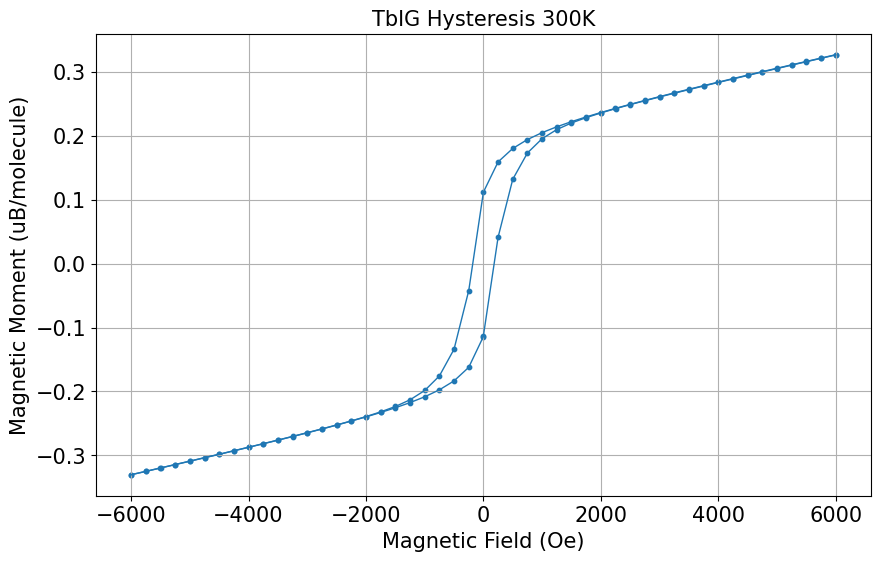

Volume Susceptibility = 0.050309751037014114


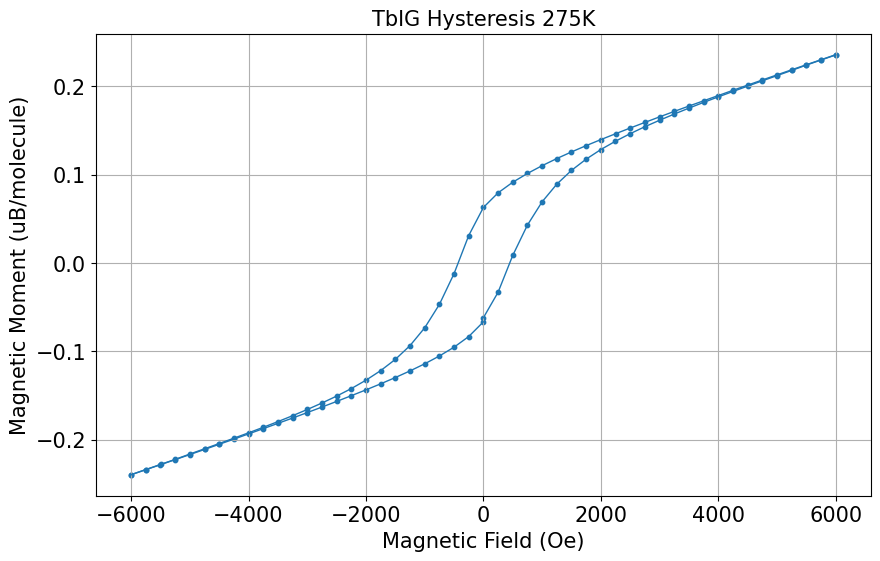

Volume Susceptibility = 0.017381198398260175


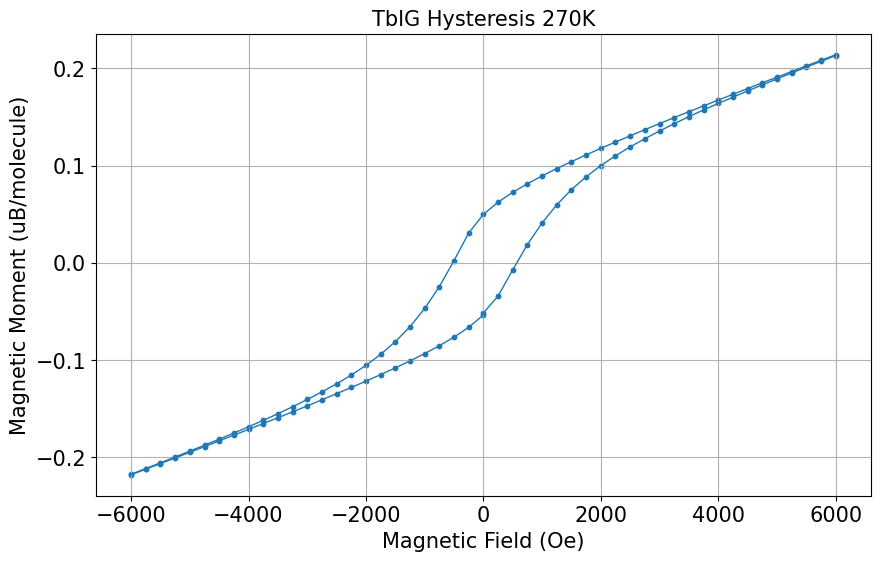

Volume Susceptibility = 0.013156708639558446


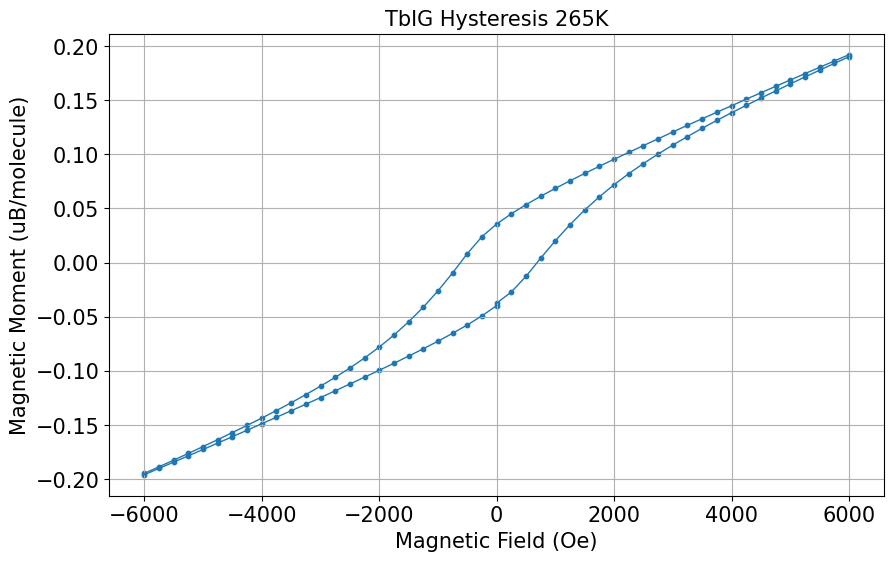

Volume Susceptibility = 0.009900150273446814


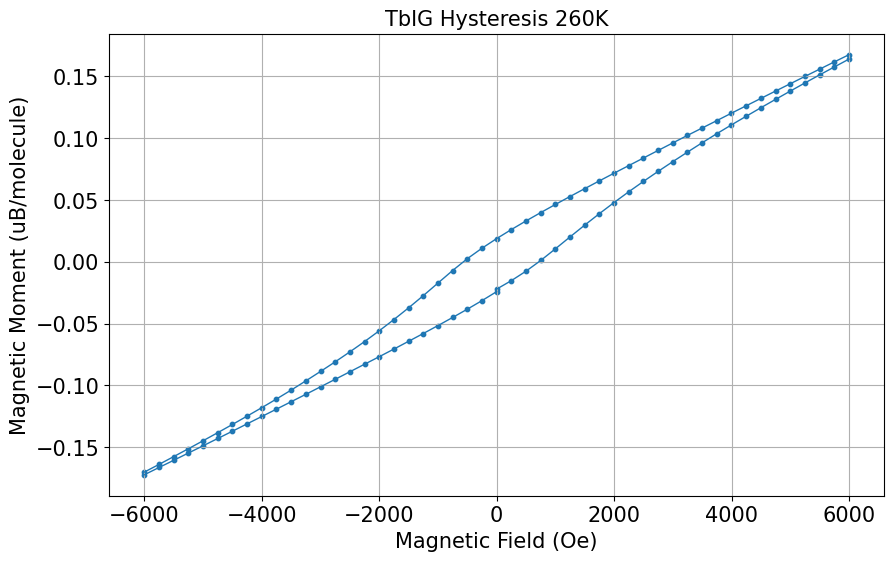

Volume Susceptibility = 0.007600020541328102


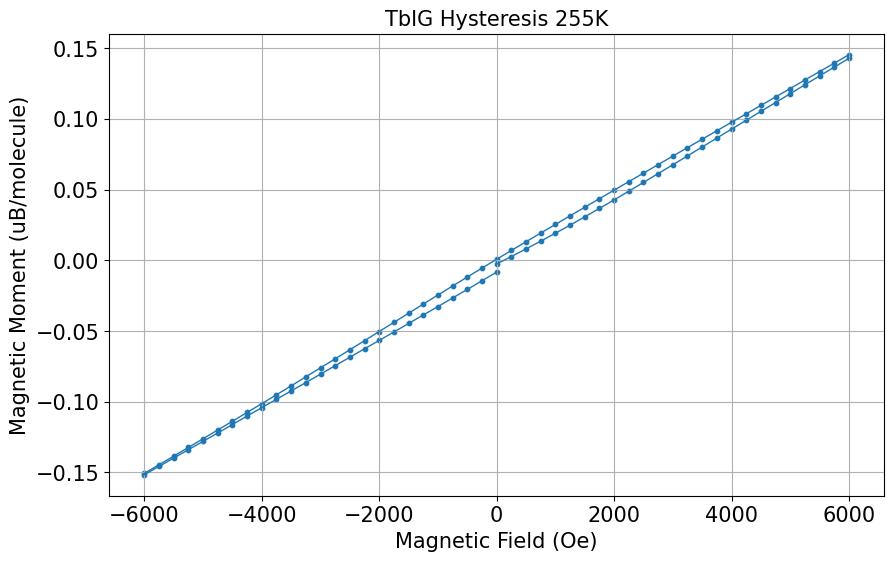

Volume Susceptibility = 0.006443220171637864


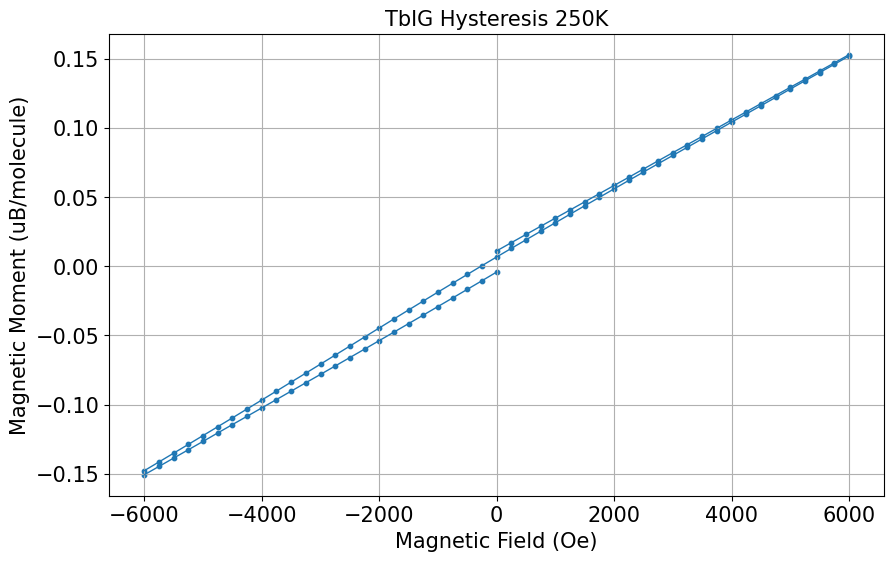

Volume Susceptibility = 0.006558691624852103


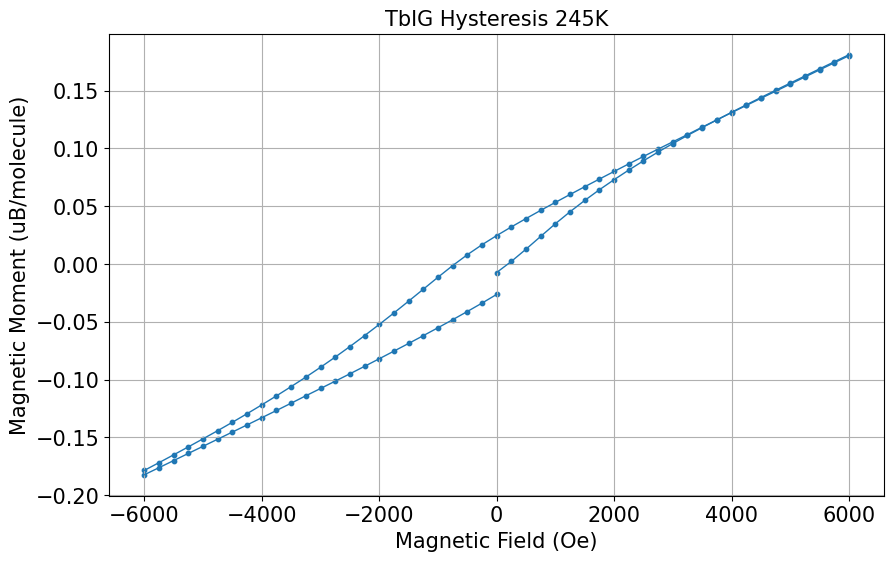

Volume Susceptibility = 0.007861044531483345


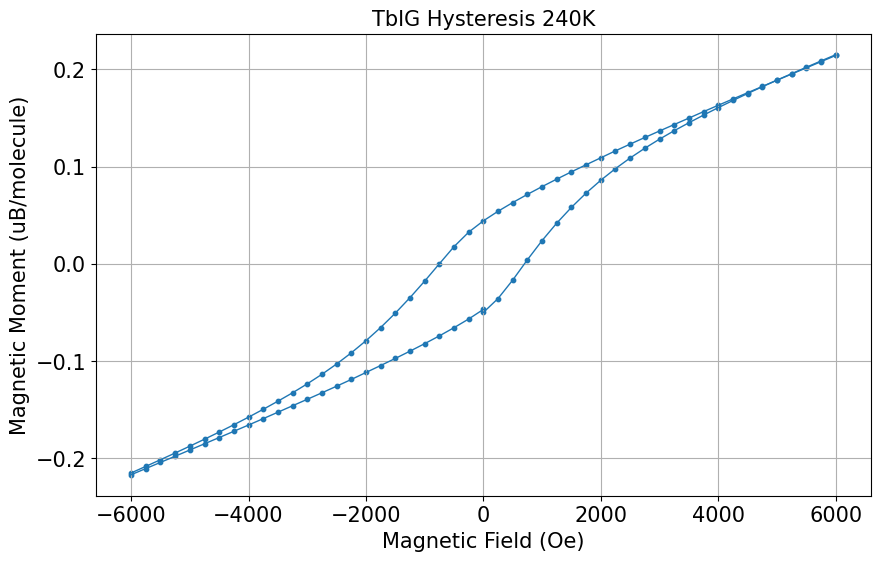

Volume Susceptibility = 0.010320444809663707


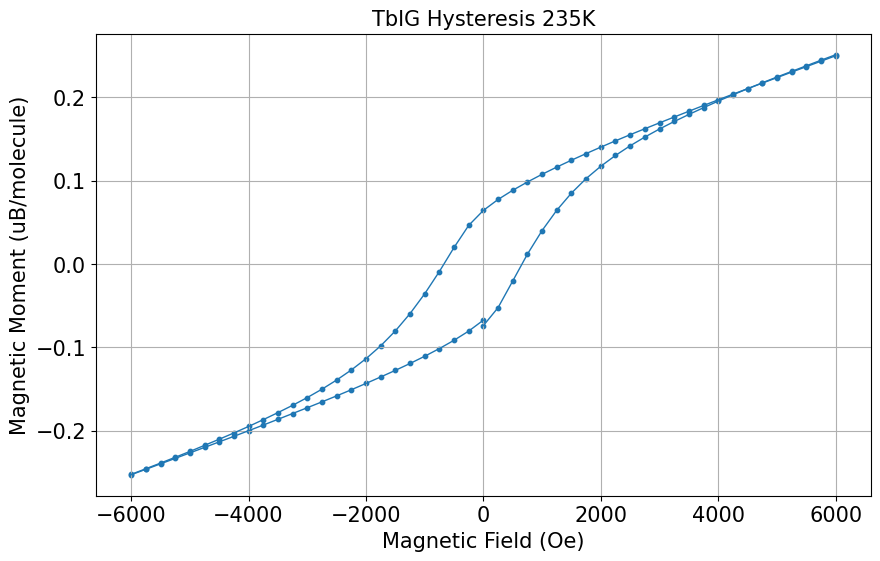

Volume Susceptibility = 0.013730446137696738


In [10]:

for i in np.arange(len(datas)):
    Hysteresis(fields[i],moments[i],momenterrors[i],"TbIG")


In [9]:
convdyig=uB/massdyig*molarmassdyig/NA




In [11]:
print(-0.025*convtbig)
print(0.02*convtbig)

-0.048225435185383
0.0385803481483064


In [11]:
#at tc+10, data moment is 0.02 emu
#at tc-10, data moment is -0.025

In [14]:
moments=np.array((-.1547,-.121,-.09,-.062,-0.0357,-.012,.0089,.0276,.044,.0582,.0749))
ubmoments=convtbig*moments

In [15]:
ubmoments

array([-0.29345873, -0.22953139, -0.17072583, -0.11761113, -0.06772125,
       -0.02276344,  0.01688289,  0.05235592,  0.08346596,  0.1104027 ,
        0.14208183])

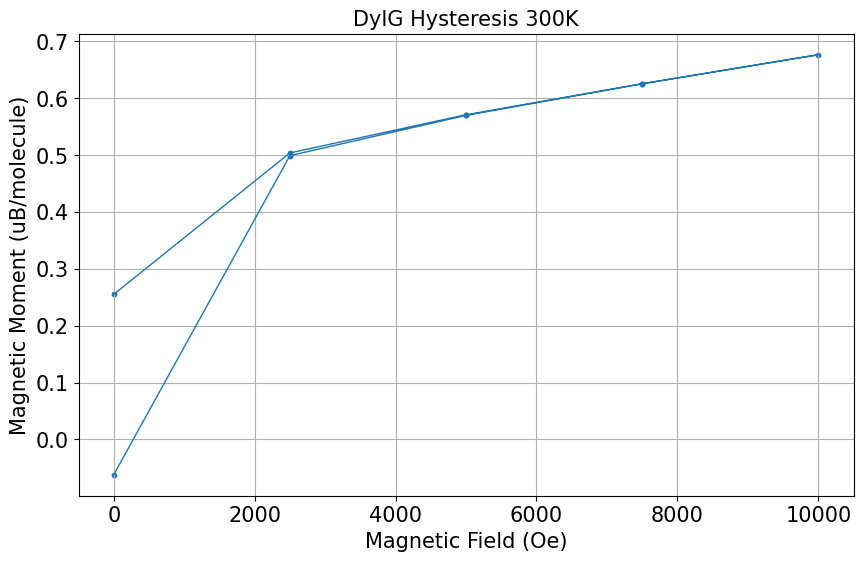

Volume Susceptibility = 0.021012099194075158


In [12]:
fielddyig=np.float64(datadyig[3][start:end])
momentdyig = np.float64(datadyig[4][start:end])
momenterrordyig = np.float64(datadyig[5][start:end])
i=0
Hysteresis(fielddyig,momentdyig,momenterrordyig,"DyIG")


In [42]:
convn=1/(volcontam/1000)*masscontam/molarmasstbig #dimensionless to mol/cc, not useful

In [43]:
-760*convn

-3.0452044030106604